# Set 11 - K-Means und Clusterbewertung

K-Means findet kompakte Gruppen um Zentren. An synthetischen Daten untersuchen wir Skalierung, Wahl von K, interne Metriken und Stabilität.

Die beim Erzeugen bekannten Gruppenlabels werden ausschließlich am Ende als didaktische Kontrolle verwendet. Das Clustering selbst erhält keine Labels.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Daten und das Skalenproblem

Der zweite Sensor wird in einer 30-mal größeren Einheit gespeichert. Euklidische Distanzen werden dadurch ohne Skalierung fast vollständig von dieser Achse bestimmt.


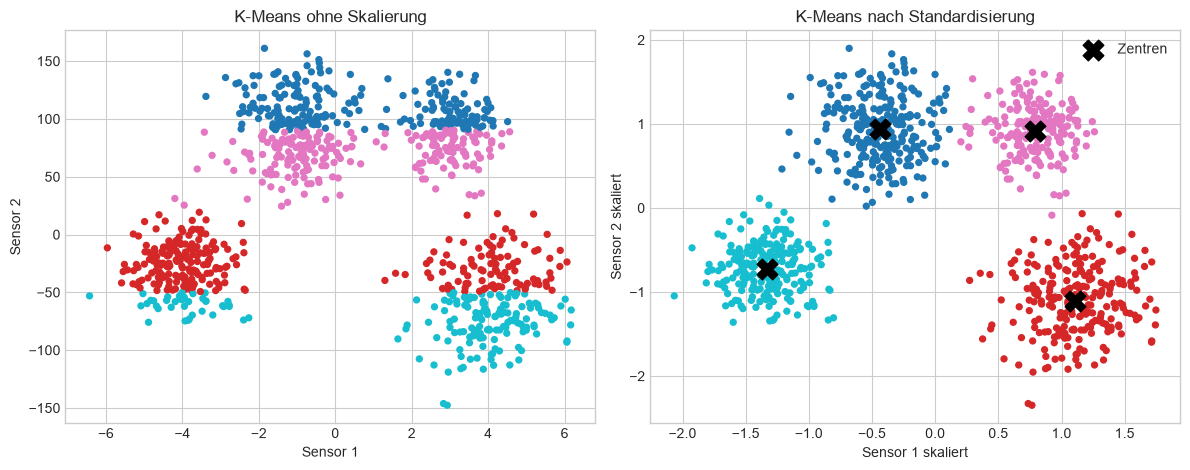

Nur didaktische Kontrolle mit verborgenen Labels:
ARI ohne Skalierung: 0.391
ARI mit Skalierung: 0.975


In [2]:
X_base, hidden_groups = make_blobs(
    n_samples=[230, 270, 190, 240],
    centers=[(-4, -1), (-1, 3), (3, 3), (4, -2)],
    cluster_std=[0.75, 0.9, 0.65, 1.0],
    random_state=RANDOM_STATE,
)
X = np.c_[X_base[:, 0], X_base[:, 1]*30]
X_scaled = StandardScaler().fit_transform(X)

raw_labels = KMeans(n_clusters=4, n_init=20, random_state=RANDOM_STATE).fit_predict(X)
scaled_model = KMeans(n_clusters=4, n_init=20, random_state=RANDOM_STATE).fit(X_scaled)
scaled_labels = scaled_model.labels_

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(X[:, 0], X[:, 1], c=raw_labels, cmap="tab10", s=18)
axes[0].set(title="K-Means ohne Skalierung", xlabel="Sensor 1", ylabel="Sensor 2")
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=scaled_labels, cmap="tab10", s=18)
axes[1].scatter(
    scaled_model.cluster_centers_[:, 0], scaled_model.cluster_centers_[:, 1],
    marker="X", s=220, c="black", label="Zentren"
)
axes[1].set(title="K-Means nach Standardisierung", xlabel="Sensor 1 skaliert", ylabel="Sensor 2 skaliert")
axes[1].legend(); plt.tight_layout(); plt.show()

print("Nur didaktische Kontrolle mit verborgenen Labels:")
print("ARI ohne Skalierung:", round(adjusted_rand_score(hidden_groups, raw_labels), 3))
print("ARI mit Skalierung:", round(adjusted_rand_score(hidden_groups, scaled_labels), 3))


## 2. K mit mehreren internen Metriken wählen

- Inertia wird mit wachsendem K immer kleiner; gesucht wird ein Knick.
- Silhouette und Calinski-Harabasz sollen groß sein.
- Davies-Bouldin soll klein sein.

Keine dieser Metriken kennt die fachliche Bedeutung der Gruppen.


,K,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,1054.453,0.465,1.068,708.943
1,3,339.531,0.641,0.491,2075.624
2,4,170.147,0.655,0.479,3065.583
3,5,143.129,0.577,0.702,2773.899
4,6,117.008,0.523,0.780,2752.839
5,7,104.382,0.438,0.910,2587.359
6,8,93.977,0.379,0.993,2475.302


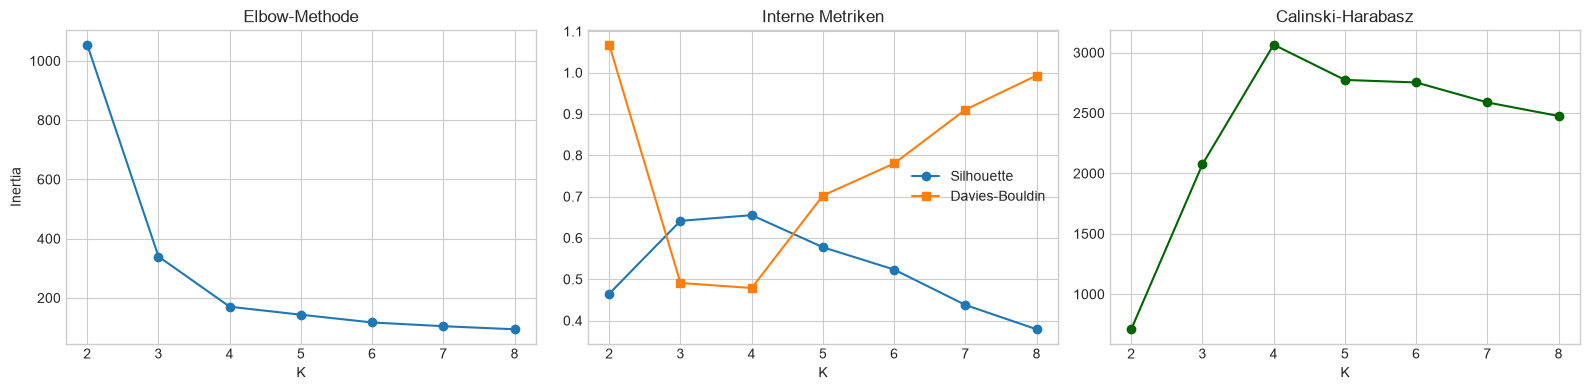

In [3]:
rows = []
fitted = {}
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X_scaled)
    fitted[k] = model
    rows.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X_scaled, model.labels_),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, model.labels_),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, model.labels_),
    })

metrics = pd.DataFrame(rows)
display(metrics.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(metrics["K"], metrics["Inertia"], marker="o")
axes[0].set(title="Elbow-Methode", xlabel="K", ylabel="Inertia")
axes[1].plot(metrics["K"], metrics["Silhouette"], marker="o", label="Silhouette")
axes[1].plot(metrics["K"], metrics["Davies-Bouldin"], marker="s", label="Davies-Bouldin")
axes[1].set(title="Interne Metriken", xlabel="K"); axes[1].legend()
axes[2].plot(metrics["K"], metrics["Calinski-Harabasz"], marker="o", color="darkgreen")
axes[2].set(title="Calinski-Harabasz", xlabel="K")
plt.tight_layout(); plt.show()


## 3. Silhouette einzelner Punkte

Der Mittelwert kann verbergen, dass einige Punkte zwischen Gruppen liegen. Negative Werte deuten auf möglicherweise unpassende Zuordnungen hin.


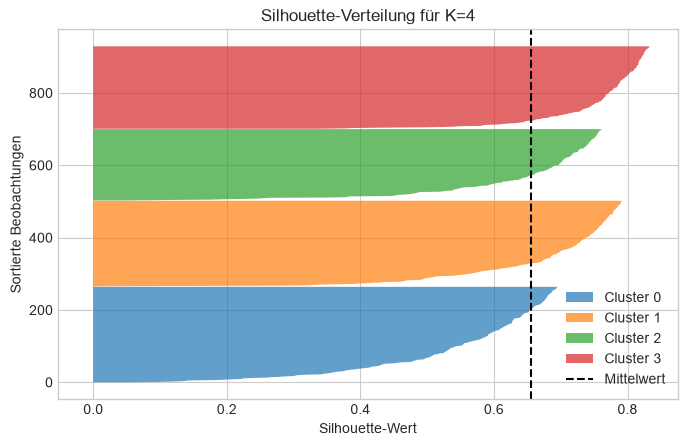

Mittlerer Score: 0.655
Anteil negativer Werte: 0.001


In [4]:
chosen_k = 4
chosen_labels = fitted[chosen_k].labels_
sample_scores = silhouette_samples(X_scaled, chosen_labels)

fig, ax = plt.subplots(figsize=(8, 4.8))
start = 0
for cluster_id in range(chosen_k):
    values = np.sort(sample_scores[chosen_labels == cluster_id])
    ax.fill_betweenx(
        np.arange(start, start + len(values)), 0, values,
        alpha=0.7, label=f"Cluster {cluster_id}"
    )
    start += len(values)
ax.axvline(sample_scores.mean(), color="black", linestyle="--", label="Mittelwert")
ax.set(xlabel="Silhouette-Wert", ylabel="Sortierte Beobachtungen",
       title="Silhouette-Verteilung für K=4")
ax.legend(); plt.show()

print("Mittlerer Score:", round(sample_scores.mean(), 3))
print("Anteil negativer Werte:", round(np.mean(sample_scores < 0), 3))


## 4. Initialisierung und Stabilität

K-Means optimiert iterativ und kann bei ungünstiger Initialisierung in verschiedenen lokalen Lösungen enden. Mehrere Starts über n_init senken dieses Risiko. Für die Demonstration teilen wir die sichtbaren vier Gruppen absichtlich mit K=5 auf; gerade bei einer solchen nicht eindeutigen Wahl können Starts variieren.


In [5]:
reference = KMeans(
    n_clusters=5, n_init=50, random_state=RANDOM_STATE
).fit(X_scaled)

stability = []
for seed in range(12):
    single = KMeans(n_clusters=5, n_init=1, random_state=seed).fit(X_scaled)
    stability.append({
        "Seed": seed,
        "Inertia": single.inertia_,
        "Übereinstimmung mit Referenz (ARI)": adjusted_rand_score(
            reference.labels_, single.labels_
        ),
    })
stability = pd.DataFrame(stability)
display(stability.round(3))
print("Inertia-Spannweite:", round(stability["Inertia"].max()-stability["Inertia"].min(), 3))


,Seed,Inertia,Übereinstimmung mit Referenz (ARI)
0,0,144.054,0.781
1,1,144.045,0.781
2,2,157.350,0.809
3,3,144.025,0.779
4,4,143.129,1.000
5,5,144.026,0.781
6,6,144.060,0.781
7,7,144.060,0.781
8,8,157.350,0.809
9,9,143.129,1.000


Inertia-Spannweite: 15.377


## Fazit

- Skalierung bestimmt bei distanzbasierten Verfahren die Geometrie.
- K-Means bevorzugt kompakte, ungefähr kugelförmige Cluster.
- Elbow und interne Metriken sind Entscheidungshilfen, keine objektive Wahrheit.
- n_init und Stabilitätsanalysen schützen vor zufälligen Einzellösungen.
- Clusterlabels sind nur Nummern und nicht automatisch fachliche Klassen.
